# Mushroom Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,roc_auc_score
import seaborn as sns

In [2]:
# Load the data
data = pd.read_csv("mushrooms.csv")
pd.set_option("display.max_columns",None)
data

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,e,?,s,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,t,?,s,k,w,w,p,w,o,e,w,v,l


In [3]:
# EDA
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [4]:
for column in data.columns:
    print(f"{column} - {data[column].isnull().sum()}")

class - 0
cap-shape - 0
cap-surface - 0
cap-color - 0
bruises - 0
odor - 0
gill-attachment - 0
gill-spacing - 0
gill-size - 0
gill-color - 0
stalk-shape - 0
stalk-root - 0
stalk-surface-above-ring - 0
stalk-surface-below-ring - 0
stalk-color-above-ring - 0
stalk-color-below-ring - 0
veil-type - 0
veil-color - 0
ring-number - 0
ring-type - 0
spore-print-color - 0
population - 0
habitat - 0


In [5]:
for column in data.columns:
    print(f"{column} - {data[column].nunique()}")

class - 2
cap-shape - 6
cap-surface - 4
cap-color - 10
bruises - 2
odor - 9
gill-attachment - 2
gill-spacing - 2
gill-size - 2
gill-color - 12
stalk-shape - 2
stalk-root - 5
stalk-surface-above-ring - 4
stalk-surface-below-ring - 4
stalk-color-above-ring - 9
stalk-color-below-ring - 9
veil-type - 1
veil-color - 4
ring-number - 3
ring-type - 5
spore-print-color - 9
population - 6
habitat - 7


In [6]:
data["class"].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

In [7]:
class_ = {"e":0,"p":1}
data["class"] = data["class"].map(class_)
data["class"]

0       1
1       0
2       0
3       1
4       0
       ..
8119    0
8120    0
8121    0
8122    1
8123    0
Name: class, Length: 8124, dtype: int64

In [8]:
non_numeric_var = data.select_dtypes(exclude="int64").columns.to_list()
non_numeric_var

['cap-shape',
 'cap-surface',
 'cap-color',
 'bruises',
 'odor',
 'gill-attachment',
 'gill-spacing',
 'gill-size',
 'gill-color',
 'stalk-shape',
 'stalk-root',
 'stalk-surface-above-ring',
 'stalk-surface-below-ring',
 'stalk-color-above-ring',
 'stalk-color-below-ring',
 'veil-type',
 'veil-color',
 'ring-number',
 'ring-type',
 'spore-print-color',
 'population',
 'habitat']

In [9]:
data = pd.get_dummies(data = data,columns=non_numeric_var,dtype = "int32",drop_first=True)
data.head()

,class,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,cap-color_g,cap-color_n,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,bruises_t,odor_c,odor_f,odor_l,odor_m,odor_n,odor_p,odor_s,odor_y,gill-attachment_f,gill-spacing_w,gill-size_n,gill-color_e,gill-color_g,gill-color_h,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stalk-shape_t,stalk-root_b,stalk-root_c,stalk-root_e,stalk-root_r,stalk-surface-above-ring_k,stalk-surface-above-ring_s,stalk-surface-above-ring_y,stalk-surface-below-ring_k,stalk-surface-below-ring_s,stalk-surface-below-ring_y,stalk-color-above-ring_c,stalk-color-above-ring_e,stalk-color-above-ring_g,stalk-color-above-ring_n,stalk-color-above-ring_o,stalk-color-above-ring_p,stalk-color-above-ring_w,stalk-color-above-ring_y,stalk-color-below-ring_c,stalk-color-below-ring_e,stalk-color-below-ring_g,stalk-color-below-ring_n,stalk-color-below-ring_o,stalk-color-below-ring_p,stalk-color-below-ring_w,stalk-color-below-ring_y,veil-color_o,veil-color_w,veil-color_y,ring-number_o,ring-number_t,ring-type_f,ring-type_l,ring-type_n,ring-type_p,spore-print-color_h,spore-print-color_k,spore-print-color_n,spore-print-color_o,spore-print-color_r,spore-print-color_u,spore-print-color_w,spore-print-color_y,population_c,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
3,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [23]:
X = data.drop(columns = "class",axis=1)
y = data["class"]
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((6499, 95), (1625, 95), (6499,), (1625,))

In [39]:
# Decision Tree
def decision_tree(X_train,X_test,y_train,y_test,max_dep,max_featu):
    Decision = DecisionTreeClassifier(max_depth=max_dep,max_features=max_featu,random_state=42)
    Decision.fit(X_train,y_train)
    Decision_preds = Decision.predict(X_test)
    accuracy = accuracy_score(y_test,Decision_preds)
    roc_auc = roc_auc_score(y_test,Decision_preds)
    sns.barplot(x = ["Accuracy-score","Roc-Auc-Score"],y = [accuracy,roc_auc])
    plt.title("Decision Tree Classifier Model Result")
    plt.xlabel("Metrics")
    plt.ylabel("Values")
    plt.show()
    print("accuracy_score : ",accuracy)
    print("roc_auc_score :",roc_auc)

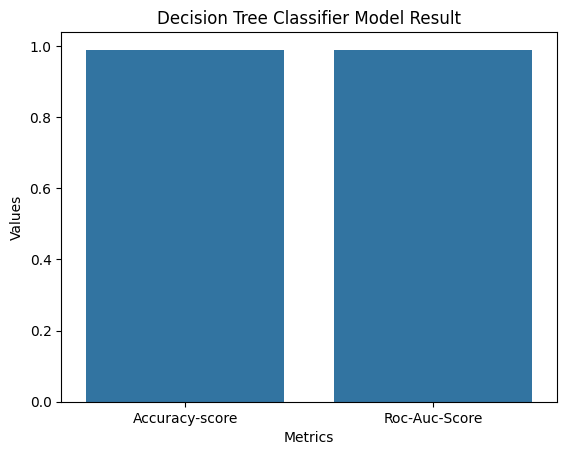

accuracy_score :  0.9895384615384616
roc_auc_score : 0.9899169632265717


In [40]:
decision_tree(X_train,X_test,y_train,y_test,max_dep=6,max_featu="sqrt")

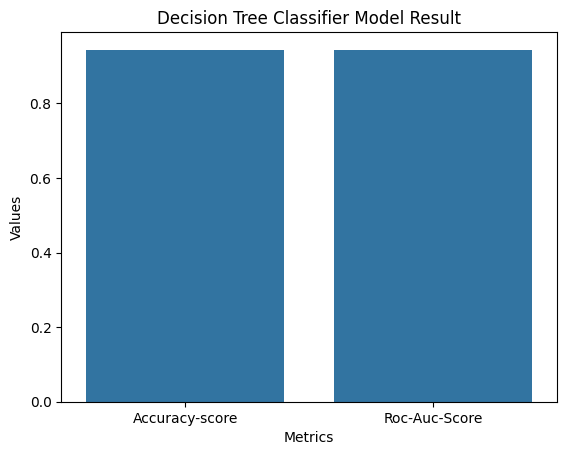

accuracy_score :  0.9427692307692308
roc_auc_score : 0.9439607964491693


In [41]:
decision_tree(X_train,X_test,y_train,y_test,max_dep=4,max_featu="sqrt")

In [42]:
# Random Forest Classifier
def random_forest(X_train,X_test,y_train,y_test,max_dep,n_estima):
    Random = RandomForestClassifier(max_depth=max_dep,n_estimators=n_estima,random_state=42)
    Random.fit(X_train,y_train)
    Random_preds = Random.predict(X_test)
    accuracy = accuracy_score(y_test,Random_preds)
    roc_auc = roc_auc_score(y_test,Random_preds)
    sns.barplot(x = ["Accuracy-score","Roc-Auc-Score"],y = [accuracy,roc_auc],color="red")
    plt.title("Random Forest Classifier Model Result")
    plt.xlabel("Metrics")
    plt.ylabel("Values")
    plt.show()
    print("accuracy_score : ",accuracy)
    print("roc_auc_score :",roc_auc)

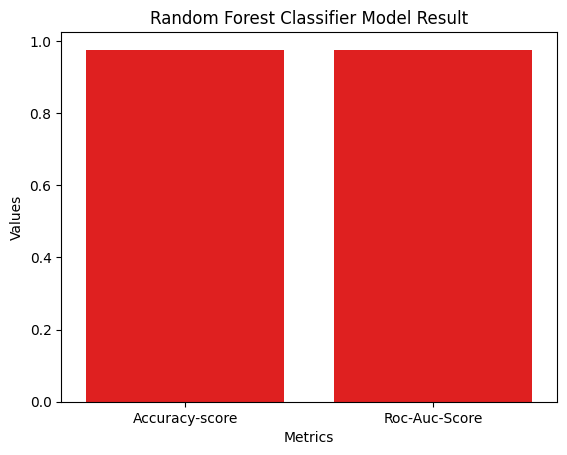

accuracy_score :  0.9753846153846154
roc_auc_score : 0.9744245524296675


In [38]:
random_forest(X_train,X_test,y_train,y_test,max_dep=3,n_estima=1000)